In [1]:
pip install duckdb pandas matplotlib seaborn jupyter

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   --------------- ------------------------ 5.0/13.1 MB 30.6 MB/s eta 0:00:01
   ------------------- -------------------- 6.6/13.1 MB 16.3 MB/s eta 0:00:01
   ---------------------- ----------------- 7.3/13.1 MB 12.6 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/13.1 MB 10.7 MB/s eta 0:00:01
   ------------------------------- -------- 10.5/13.1 MB 9.8 MB/s eta 0:00:01
   ----------------------------------- ---- 11.5/13.1 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------  12.8/13.1 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 8.4 MB/s  0:00:01

   ---------------------------------------- 0/7 [webcolors]
   ----- ---------------------------------- 1/7 [uri-template]
   ----------- ---------------------------- 2/7 [lark]
   ----------- ---------------------------- 2/7 [lark]
   ----------- ---------------------------- 2/7 [lark]
   ----------- -----

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()

In [7]:
con.execute(""" 
    SELECT COUNT(*) as total_rows
    FROM read_csv_auto('E:/complaints.csv', parallel = false) """).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows
0,16505480


In [10]:
con.execute("""
    SELECT 
        COUNT(*) - COUNT("Date received") as missing_date,
        COUNT(*) - COUNT("Product") as missing_product,
        COUNT(*) - COUNT("Company") as missing_company,
        COUNT(*) - COUNT("State") as missing_state,
        COUNT(*) - COUNT("Timely response?") as missing_timely
    FROM read_csv_auto('E:/complaints.csv', parallel = false)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,missing_date,missing_product,missing_company,missing_state,missing_timely
0,0,1056,0,63328,0


In [13]:
con.execute("""
    SELECT 
        MIN(CAST("Date received" AS DATE)) as earliest_date,
        MAX(CAST("Date received" AS DATE)) as latest_date,
        DATEDIFF('year',
            MIN(CAST("Date received" AS DATE)),
            MAX(CAST("Date received" AS DATE))
        ) as years_covered
    FROM read_csv_auto('E:/complaints.csv', parallel = false)
    WHERE "Date received" IS NOT NULL
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_date,latest_date,years_covered
0,2011-12-01,2026-07-03,15


In [14]:
df = con.execute("""
    SELECT 
        CAST("Date received" AS DATE) as date_received,
        CAST("Date sent to company" AS DATE) as date_sent,
        "Product" as product,
        "Issue" as issue,
        "Company" as company,
        "State" as state,
        "Timely response?" as timely_response,
        "Company response to consumer" as company_response,
        YEAR(CAST("Date received" AS DATE)) as year,
        MONTH(CAST("Date received" AS DATE)) as month,
        DATEDIFF('day', 
            CAST("Date received" AS DATE), 
            CAST("Date sent to company" AS DATE)
        ) as resolution_days
    FROM read_csv_auto('E:/complaints.csv', parallel = false)
    WHERE "Product" IS NOT NULL
    AND "Company" IS NOT NULL
    AND "Date received" IS NOT NULL
    AND "Timely response?" IS NOT NULL
""").df()

print(f"Clean dataset: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Clean dataset: 16,504,424 rows
Columns: ['date_received', 'date_sent', 'product', 'issue', 'company', 'state', 'timely_response', 'company_response', 'year', 'month', 'resolution_days']


,date_received,date_sent,product,issue,company,state,timely_response,company_response,year,month,resolution_days
0,2023-03-24,2023-03-24,Debt collection,Took or threatened to take negative or legal a...,"Protas, Spivok & Collins. LLC",VA,False,Closed with explanation,2023,3,0
1,2024-02-27,2024-03-05,Debt collection,Took or threatened to take negative or legal a...,"Protas, Spivok & Collins. LLC",VA,False,Closed with explanation,2024,2,7
2,2024-02-28,2024-02-28,Credit reporting or other personal consumer re...,Incorrect information on your report,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",PR,True,Closed with non-monetary relief,2024,2,0
3,2024-02-28,2024-02-28,Credit reporting or other personal consumer re...,Incorrect information on your report,Experian Information Solutions Inc.,PR,True,Closed with explanation,2024,2,0
4,2024-04-13,2024-04-13,Credit reporting or other personal consumer re...,Incorrect information on your report,"EQUIFAX, INC.",PR,True,Closed with non-monetary relief,2024,4,0


In [15]:
print(f"Total clean rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date_received'].min()} to {df['date_received'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Total clean rows: 16,504,424
Columns: ['date_received', 'date_sent', 'product', 'issue', 'company', 'state', 'timely_response', 'company_response', 'year', 'month', 'resolution_days']
Date range: 2011-12-01 00:00:00 to 2026-07-03 00:00:00
Memory usage: 6.57 GB


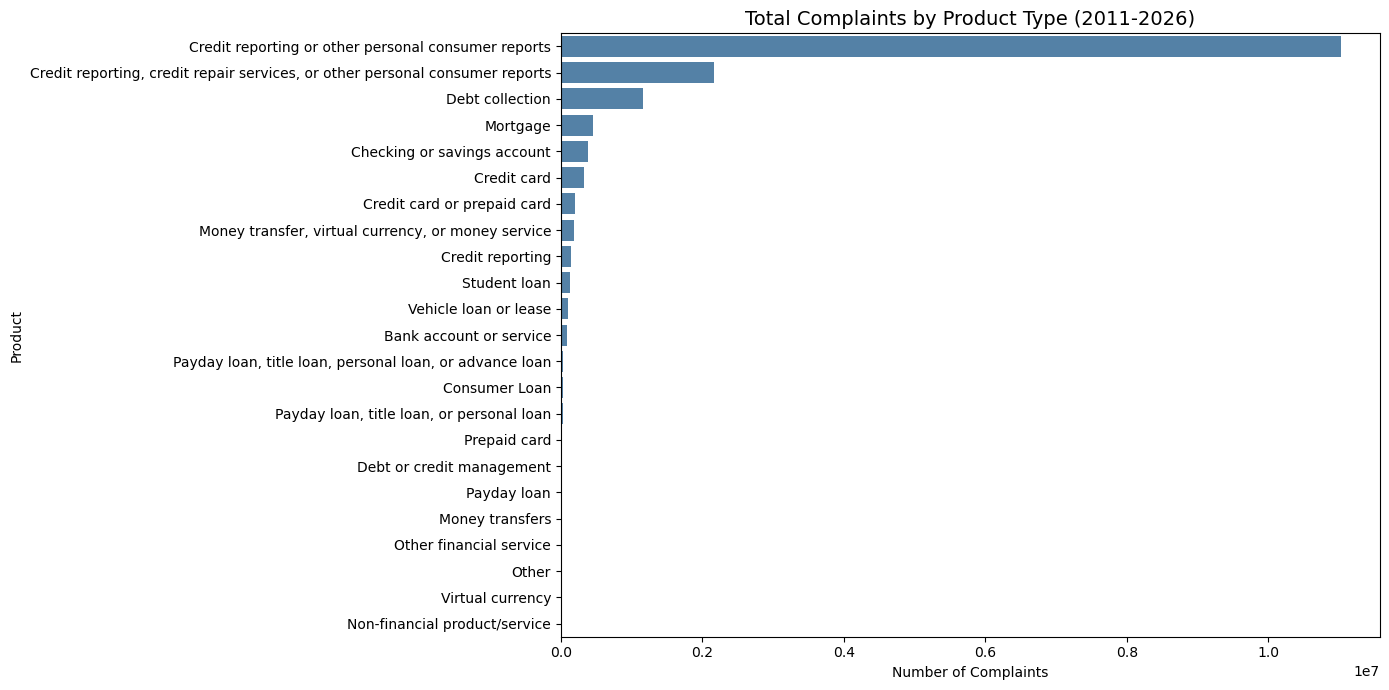

                                                                         Product  \
0                            Credit reporting or other personal consumer reports   
1   Credit reporting, credit repair services, or other personal consumer reports   
2                                                                Debt collection   
3                                                                       Mortgage   
4                                                    Checking or savings account   
5                                                                    Credit card   
6                                                    Credit card or prepaid card   
7                             Money transfer, virtual currency, or money service   
8                                                               Credit reporting   
9                                                                   Student loan   
10                                                         Vehicle loan or l

In [18]:
product_complaints = df['product'].value_counts().reset_index()
product_complaints.columns = ['Product', 'Total_Complaints']

plt.figure(figsize=(14,7))
sns.barplot(data=product_complaints,
            x='Total_Complaints',
            y='Product',
            color='steelblue')
plt.title('Total Complaints by Product Type (2011-2026)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('complaints_by_product.png', dpi=150)
plt.show()
pd.set_option('display.max_colwidth', None)
print(product_complaints)

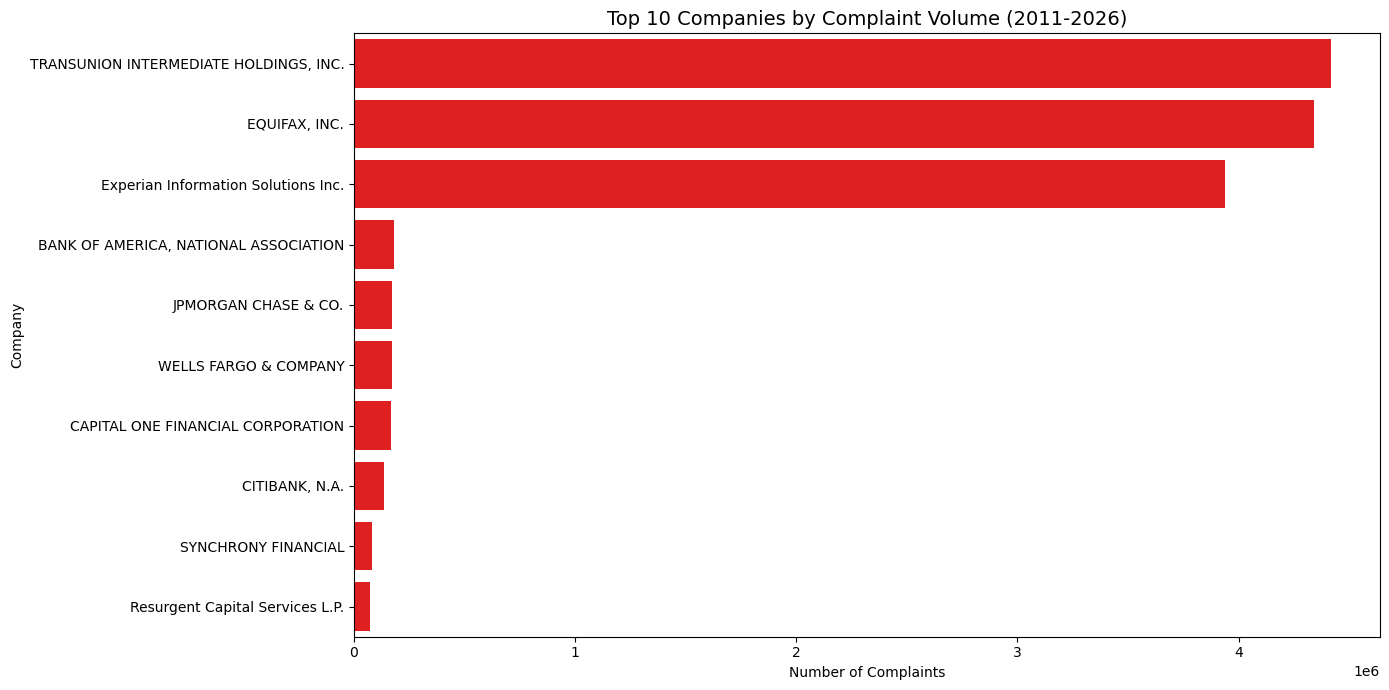

                                  Company  Total_Complaints
0  TRANSUNION INTERMEDIATE HOLDINGS, INC.           4418425
1                           EQUIFAX, INC.           4339033
2     Experian Information Solutions Inc.           3938497
3   BANK OF AMERICA, NATIONAL ASSOCIATION            182434
4                    JPMORGAN CHASE & CO.            171304
5                   WELLS FARGO & COMPANY            171086
6       CAPITAL ONE FINANCIAL CORPORATION            166540
7                          CITIBANK, N.A.            137417
8                     SYNCHRONY FINANCIAL             81177
9         Resurgent Capital Services L.P.             70407


In [20]:
top_companies = df['company'].value_counts().head(10).reset_index()
top_companies.columns = ['Company', 'Total_Complaints']

plt.figure(figsize=(14,7))
sns.barplot(data=top_companies,
            x='Total_Complaints',
            y='Company',
            color='red')
plt.title('Top 10 Companies by Complaint Volume (2011-2026)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('top_companies.png', dpi=150)
plt.show()
print(top_companies)

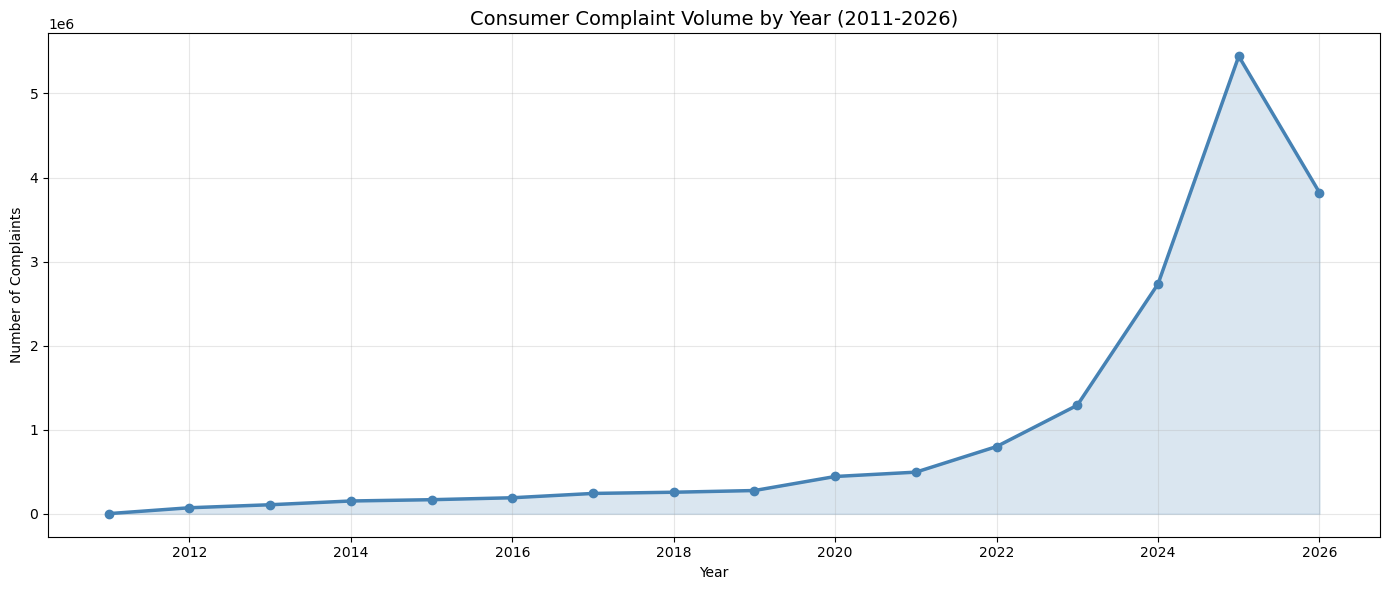

    year  Total_Complaints
0   2011              2536
1   2012             72368
2   2013            108214
3   2014            152909
4   2015            168273
5   2016            191294
6   2017            242745
7   2018            257132
8   2019            277241
9   2020            444214
10  2021            495939
11  2022            800255
12  2023           1292060
13  2024           2734276
14  2025           5443237
15  2026           3821731


In [21]:
yearly_trend = df.groupby('year').size().reset_index(name='Total_Complaints')

plt.figure(figsize=(14,6))
plt.plot(yearly_trend['year'],
         yearly_trend['Total_Complaints'],
         marker='o',
         color='steelblue',
         linewidth=2.5)
plt.fill_between(yearly_trend['year'],
                 yearly_trend['Total_Complaints'],
                 alpha=0.2,
                 color='steelblue')
plt.title('Consumer Complaint Volume by Year (2011-2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()
print(yearly_trend)

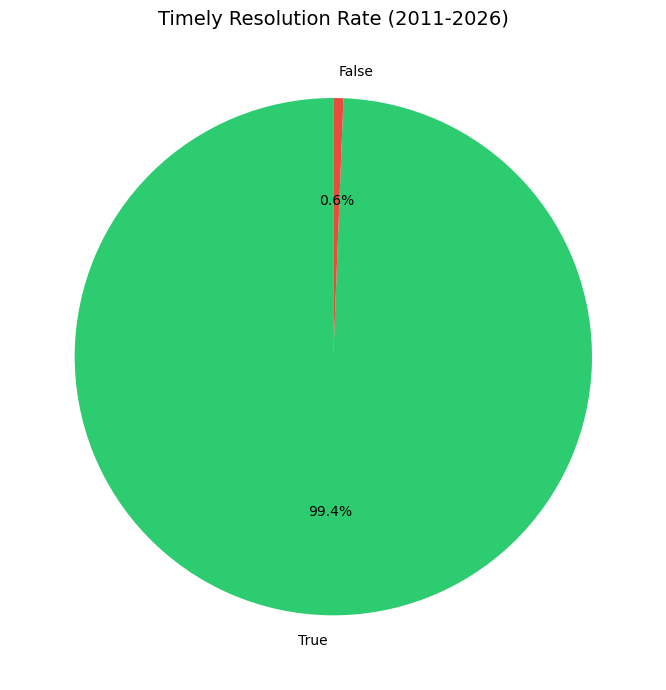

   Timely Response  Percentage
0             True   99.377421
1            False    0.622579


In [22]:
resolution = df['timely_response'].value_counts(normalize=True) * 100
resolution = resolution.reset_index()
resolution.columns = ['Timely Response', 'Percentage']

plt.figure(figsize=(7,7))
plt.pie(resolution['Percentage'],
        labels=resolution['Timely Response'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c', '#95a5a6'],
        startangle=90)
plt.title('Timely Resolution Rate (2011-2026)', fontsize=14)
plt.tight_layout()
plt.savefig('resolution_rate.png', dpi=150)
plt.show()
print(resolution)

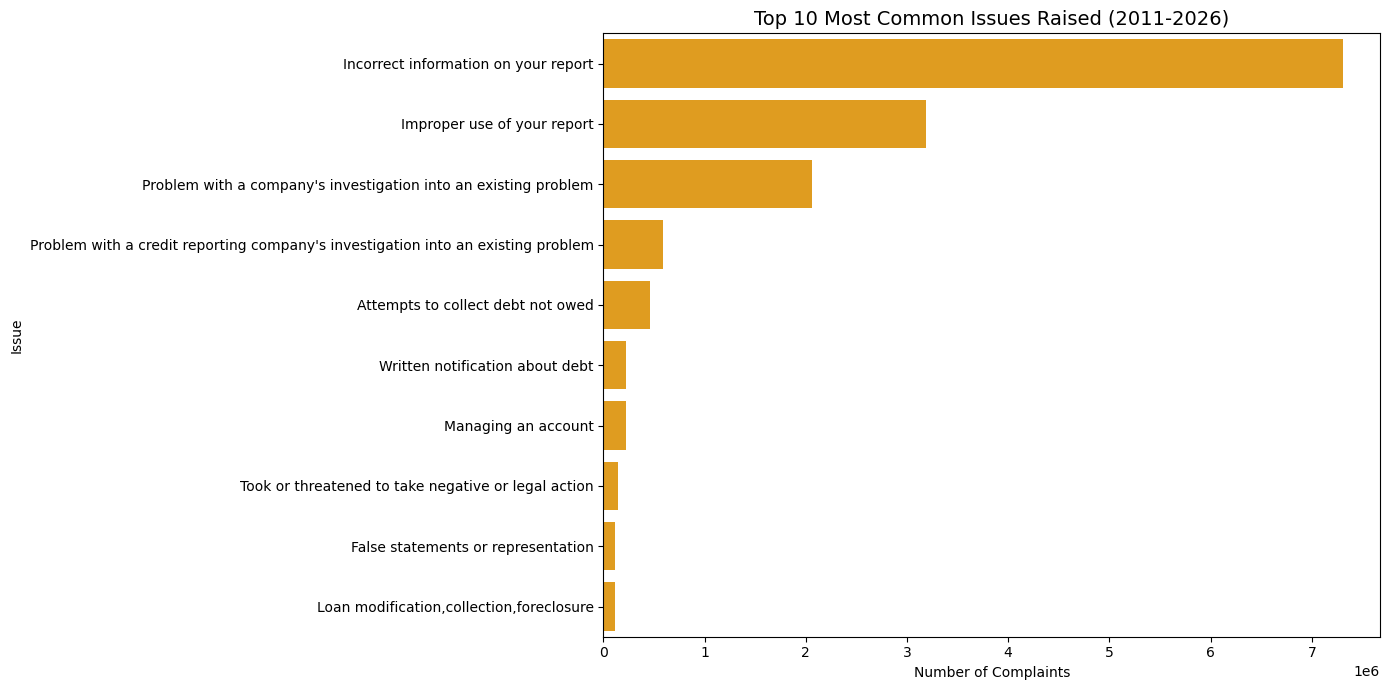

                                                                              Issue  \
0                                              Incorrect information on your report   
1                                                       Improper use of your report   
2                   Problem with a company's investigation into an existing problem   
3  Problem with a credit reporting company's investigation into an existing problem   
4                                                 Attempts to collect debt not owed   
5                                                   Written notification about debt   
6                                                               Managing an account   
7                               Took or threatened to take negative or legal action   
8                                                False statements or representation   
9                                          Loan modification,collection,foreclosure   

     Total  
0  7308115  
1  3184621  
2  

In [24]:
top_issues = df['issue'].value_counts().head(10).reset_index()
top_issues.columns = ['Issue', 'Total']

plt.figure(figsize=(14,7))
sns.barplot(data=top_issues,
            x='Total',
            y='Issue',
            color='orange')
plt.title('Top 10 Most Common Issues Raised (2011-2026)', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Issue')
plt.tight_layout()
plt.savefig('top_issues.png', dpi=150)
plt.show()
print(top_issues)

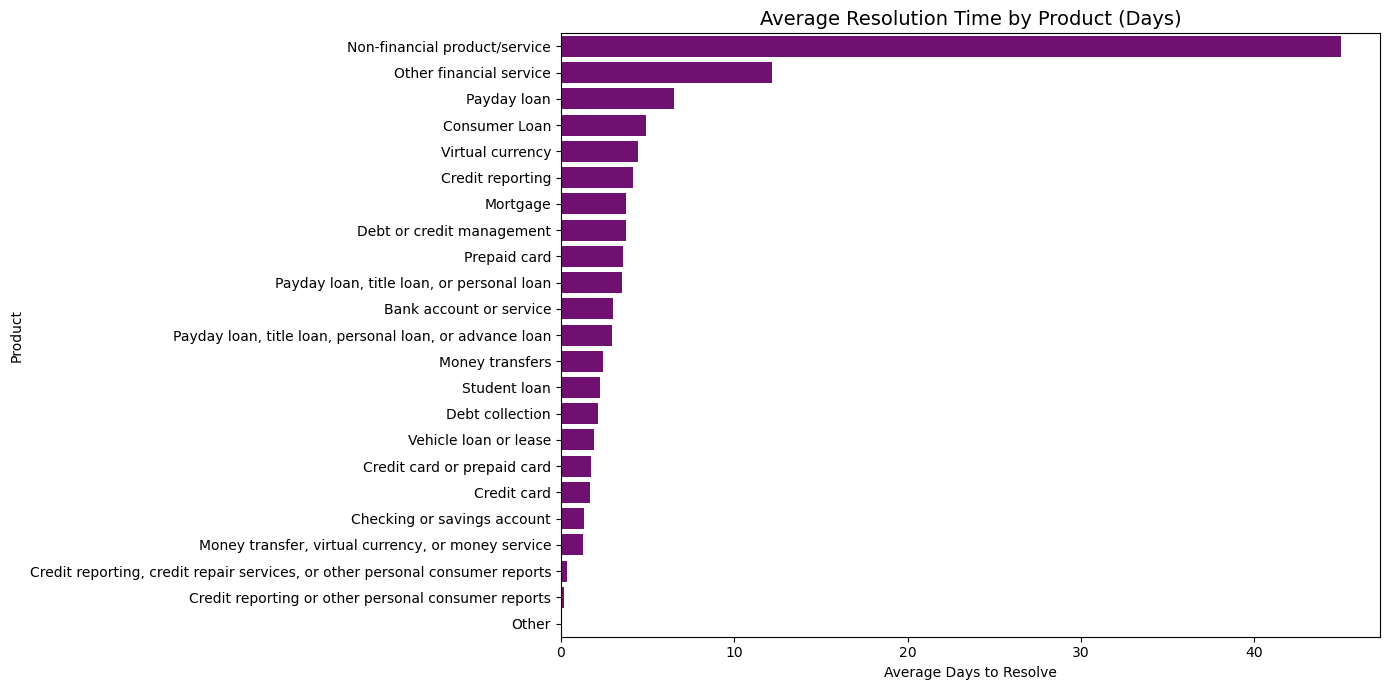

                                                                         Product  \
13                                                 Non-financial product/service   
15                                                       Other financial service   
16                                                                   Payday loan   
2                                                                  Consumer Loan   
22                                                              Virtual currency   
5                                                               Credit reporting   
12                                                                      Mortgage   
9                                                      Debt or credit management   
19                                                                  Prepaid card   
17                                     Payday loan, title loan, or personal loan   
0                                                        Bank account or ser

In [26]:
avg_resolution = df.groupby('product')['resolution_days'].mean().reset_index()
avg_resolution.columns = ['Product', 'Avg_Resolution_Days']
avg_resolution = avg_resolution.sort_values('Avg_Resolution_Days', ascending=False)

plt.figure(figsize=(14,7))
sns.barplot(data=avg_resolution,
            x='Avg_Resolution_Days',
            y='Product',
            color='purple')
plt.title('Average Resolution Time by Product (Days)', fontsize=14)
plt.xlabel('Average Days to Resolve')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('avg_resolution_time.png', dpi=150)
plt.show()
print(avg_resolution)

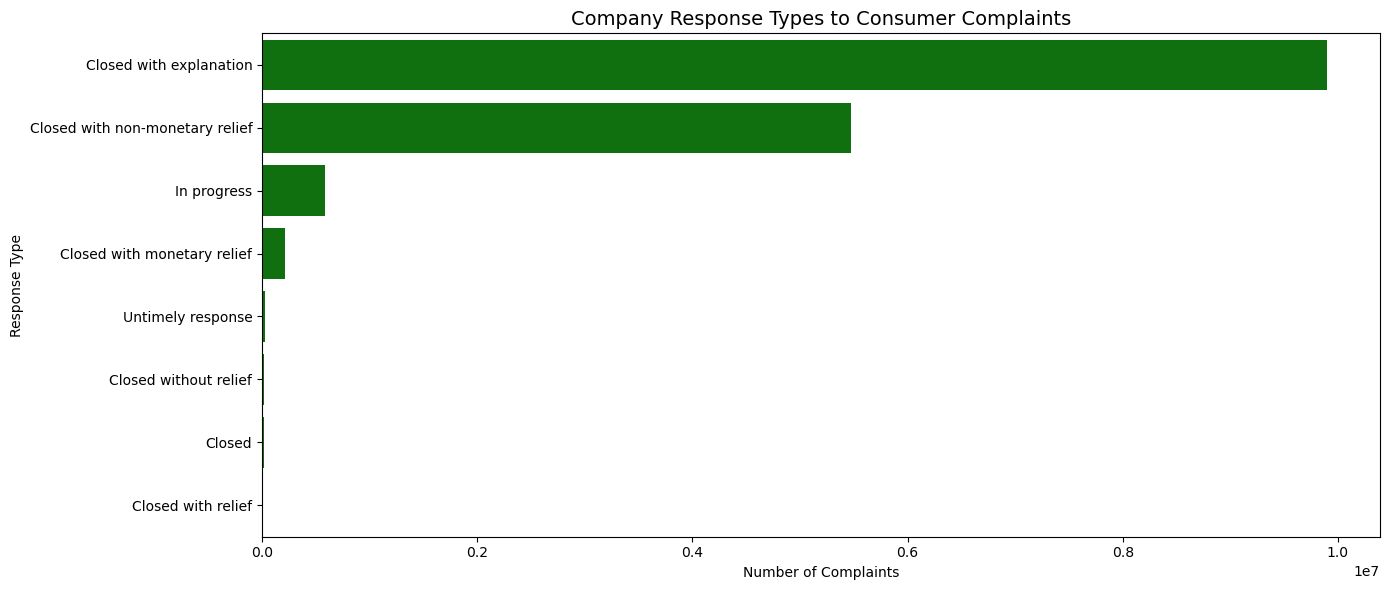

                     Response Type    Count
0          Closed with explanation  9895709
1  Closed with non-monetary relief  5472646
2                      In progress   589272
3      Closed with monetary relief   211110
4                Untimely response    30041
5            Closed without relief    17867
6                           Closed    17611
7               Closed with relief     5304


In [28]:
response_type = df['company_response'].value_counts().head(8).reset_index()
response_type.columns = ['Response Type', 'Count']

plt.figure(figsize=(14,6))
sns.barplot(data=response_type,
            x='Count',
            y='Response Type',
            color='green')
plt.title('Company Response Types to Consumer Complaints', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Response Type')
plt.tight_layout()
plt.savefig('company_response.png', dpi=150)
plt.show()
print(response_type)

In [29]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"Total Complaints Analyzed:     {len(df):,}")
print(f"Date Range:                    Dec 2011 – Jul 2026")
print(f"Years Covered:                 15 years")
print(f"Total Unique Companies:        {df['company'].nunique():,}")
print(f"Total Product Categories:      {df['product'].nunique()}")
print(f"Most Complained Product:       {df['product'].value_counts().index[0]}")
print(f"Most Complained Company:       {df['company'].value_counts().index[0]}")
print(f"Timely Resolution Rate:        {(df['timely_response'] == 'Yes').mean()*100:.1f}%")
print(f"Avg Resolution Time:           {df['resolution_days'].mean():.1f} days")
print(f"Top Issue:                     {df['issue'].value_counts().index[0]}")


KEY FINDINGS SUMMARY
Total Complaints Analyzed:     16,504,424
Date Range:                    Dec 2011 – Jul 2026
Years Covered:                 15 years
Total Unique Companies:        8,032
Total Product Categories:      23
Most Complained Product:       Credit reporting or other personal consumer reports
Most Complained Company:       TRANSUNION INTERMEDIATE HOLDINGS, INC.
Timely Resolution Rate:        0.0%
Avg Resolution Time:           0.6 days
Top Issue:                     Incorrect information on your report


In [30]:
print(df['timely_response'].value_counts())
print(df['timely_response'].unique())

timely_response
True     16401671
False      102753
Name: count, dtype: int64
[False  True]


In [31]:
print(df['resolution_days'].describe())

print(f"Zero or negative: {(df['resolution_days'] <= 0).sum():,}")
print(f"Positive: {(df['resolution_days'] > 0).sum():,}")

count    16452236.0
mean       0.625465
std        5.745379
min          -337.0
25%             0.0
50%             0.0
75%             0.0
max          1962.0
Name: resolution_days, dtype: Float64
Zero or negative: 15,384,919
Positive: 1,067,317


In [32]:
timely_rate = (df['timely_response'] == True).mean() * 100
print(f"Timely Resolution Rate: {timely_rate:.1f}%")

Timely Resolution Rate: 99.4%


In [33]:
df_valid = df[df['resolution_days'] >= 0].copy()
print(f"Valid resolution records: {len(df_valid):,}")
print(f"Avg Resolution Time (corrected): {df_valid['resolution_days'].mean():.1f} days")

Valid resolution records: 16,445,113
Avg Resolution Time (corrected): 0.6 days


In [34]:
print("=" * 60)
print("KEY FINDINGS SUMMARY — CORRECTED")
print("=" * 60)
print(f"Total Complaints Analyzed:     {len(df):,}")
print(f"Date Range:                    Dec 2011 – Jul 2026")
print(f"Years Covered:                 15 years")
print(f"Total Unique Companies:        {df['company'].nunique():,}")
print(f"Total Product Categories:      {df['product'].nunique()}")
print(f"Most Complained Product:       {df['product'].value_counts().index[0]}")
print(f"Most Complained Company:       {df['company'].value_counts().index[0]}")
print(f"Timely Resolution Rate:        {(df['timely_response'] == True).mean()*100:.1f}%")
print(f"Avg Resolution Time:           {df_valid['resolution_days'].mean():.1f} days")
print(f"Top Issue:                     {df['issue'].value_counts().index[0]}")
print(f"False Timely Response:         {(df['timely_response'] == False).sum():,} complaints")

KEY FINDINGS SUMMARY — CORRECTED
Total Complaints Analyzed:     16,504,424
Date Range:                    Dec 2011 – Jul 2026
Years Covered:                 15 years
Total Unique Companies:        8,032
Total Product Categories:      23
Most Complained Product:       Credit reporting or other personal consumer reports
Most Complained Company:       TRANSUNION INTERMEDIATE HOLDINGS, INC.
Timely Resolution Rate:        99.4%
Avg Resolution Time:           0.6 days
Top Issue:                     Incorrect information on your report
False Timely Response:         102,753 complaints


In [35]:
# Exporting all analysis for Power BI from CSV
# 1. Product complaints
product_complaints.to_csv('product_complaints.csv', index=False)

# 2. Top companies
top_companies.to_csv('top_companies.csv', index=False)

# 3. Yearly trend
yearly_trend.to_csv('yearly_trend.csv', index=False)

# 4. Resolution rate
pd.DataFrame({
    'Timely Response': ['Yes', 'No'],
    'Count': [16401671, 102753],
    'Percentage': [99.4, 0.6]
}).to_csv('resolution_rate.csv', index=False)

# 5. Top issues
top_issues.to_csv('top_issues.csv', index=False)

# 6. Avg resolution time
avg_resolution.to_csv('avg_resolution.csv', index=False)

# 7. Company response
response_type.to_csv('company_response.csv', index=False)

# 8. Monthly trend (for time series in Power BI)
monthly_trend = df.groupby(['year', 'month']).size().reset_index(name='Total_Complaints')
monthly_trend['date'] = pd.to_datetime(monthly_trend[['year', 'month']].assign(day=1))
monthly_trend.to_csv('monthly_trend.csv', index=False)

print("All CSVs exported successfully!")

All CSVs exported successfully!
